<a href="https://colab.research.google.com/github/twyeh/highenergy/blob/main/feyngraph_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q feyngraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.4/797.4 kB 11.9 MB/s eta 0:00:00


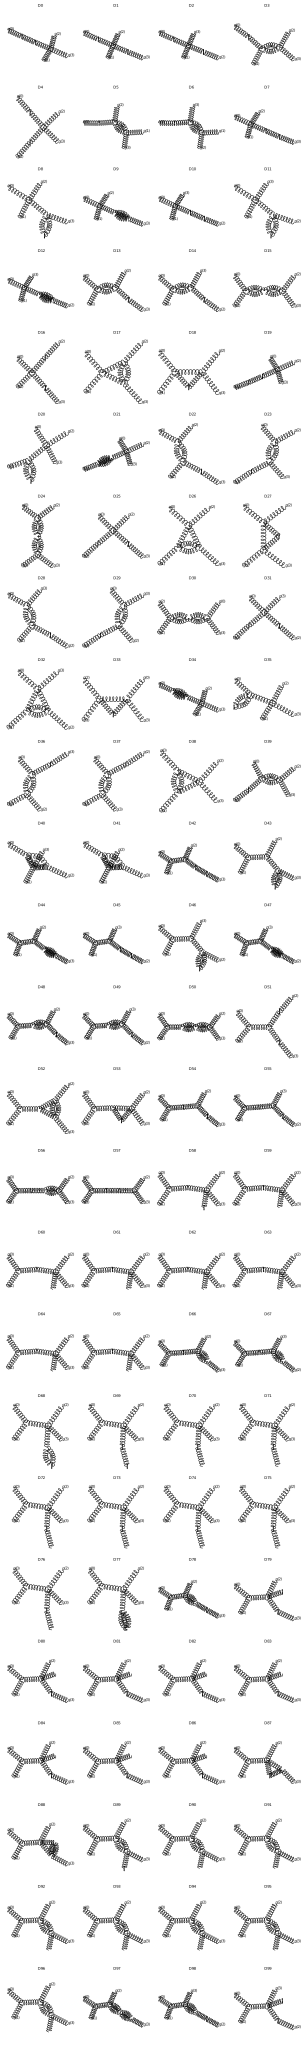

In [ ]:
import feyngraph as fg
# 生成膠子碰撞的圖表
diags = fg.generate_diagrams(["g", "g"], ["g", "g"], 2)
diags

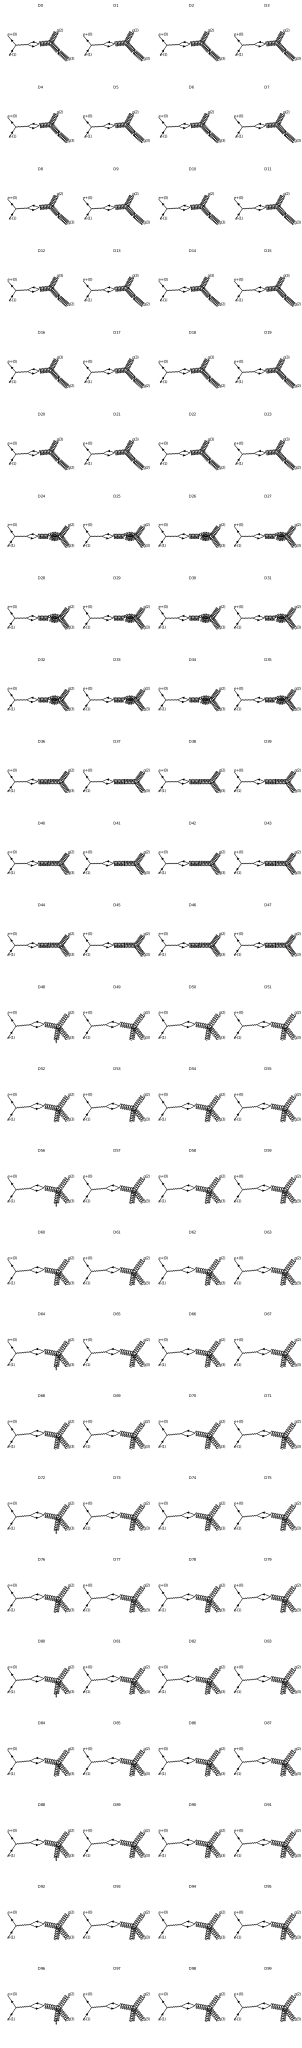

In [ ]:
import feyngraph as fg
# 生成膠子碰撞的圖表
diags = fg.generate_diagrams(["e+", "e-"], ["g", "g"], 2)
diags

In [11]:
import feyngraph as fg
def gluon_in_second_loop(d: fg.Diagram) -> bool:
  return any(p.particle().name() == "g" for p in d.chord(1))
s = fg.DiagramSelector()
s.select_on_shell()
s.select_self_loops(0)
s.add_custom_function(gluon_in_second_loop)
len(fg.generate_diagrams(["u", "u~"], ["g", "g"], 2, selector = s))
def topo_filter(topo) -> bool:
  three_loop = any(sum(c != 0 for c in e.momentum()[3:]) == 3 for e in topo.edges())
  two_tadpoles = sum(all(c == 0 for c in e.momentum()) for e in topo.edges()) == 2
  return three_loop and two_tadpoles
def diagram_filter(d: fg.Diagram) -> bool:
  gluon_tadpole = any(
  p.vertex(0).id() == p.vertex(1).id() and p.particle().name() == "g" for p in d.propagators()
  )
  Z_tadpole = any(
  p.vertex(0).id() == p.vertex(1).id() and p.particle().name() == "Z" for p in d.propagators()
  )
  fermion_loop = any(p.particle().is_fermi() for i in range(5) for p in d.chord(i))
  return gluon_tadpole and Z_tadpole and fermion_loop
s = fg.DiagramSelector()
s.select_on_shell()
s.select_self_loops(2)
s.select_vertex_degree(4, 0)
s.select_coupling_power("QED", 2)
s.add_topology_function(topo_filter)
s.add_custom_function(diagram_filter)
fg.DiagramGenerator(["g"], ["t", "t~"], 5, fg.Model(), selector = s).count()

12809

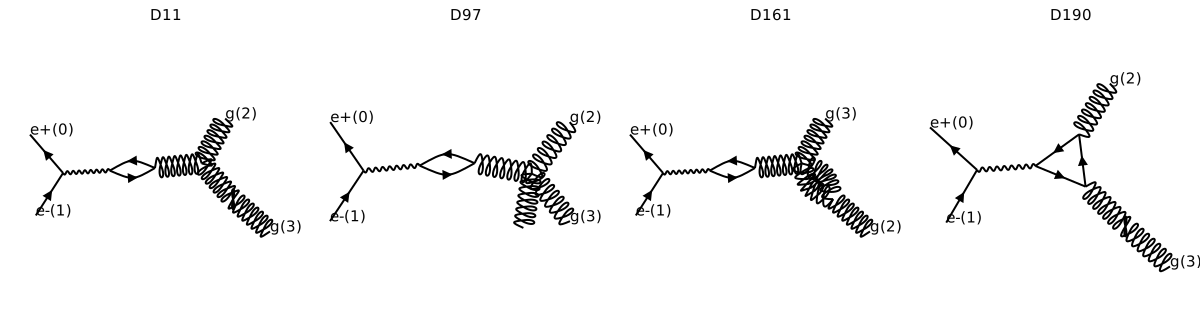

In [10]:
import feyngraph as fg
from IPython.display import SVG
diags = fg.generate_diagrams(["e+", "e-"], ["g", "g"], 2)
SVG(diags.draw([11, 97, 161, 190]))